Completed 200/2000 runs
Completed 400/2000 runs
Completed 600/2000 runs
Completed 800/2000 runs
Completed 1000/2000 runs
Completed 1200/2000 runs
Completed 1400/2000 runs
Completed 1600/2000 runs
Completed 1800/2000 runs
Completed 2000/2000 runs


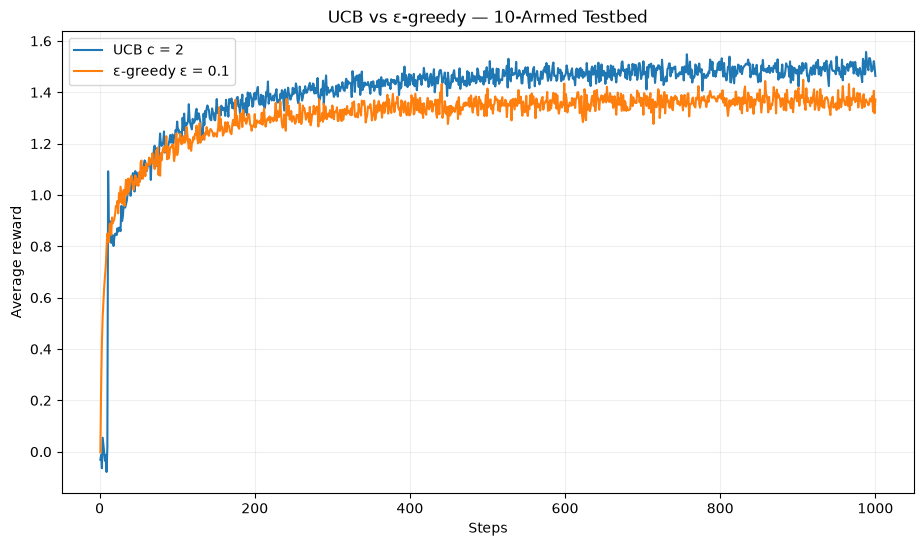

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sutton & Barto Figure 2.4
# UCB vs epsilon-greedy on the 10-armed testbed

N_ARMS = 10
N_STEPS = 1000
N_RUNS = 2000

C = 2
EPSILON = 0.1


def run_ucb(q_true):
    """
    Run one UCB agent for N_STEPS.
    """

    Q = np.zeros(N_ARMS)
    N = np.zeros(N_ARMS)
    rewards = np.zeros(N_STEPS)
    for t in range(1, N_STEPS + 1):

        # Action selection - Any untried action is selected before UCB is applied. Random tie-breaking prevents systematic preference for low-index actions.
        untried = np.flatnonzero(N == 0)
        if len(untried) > 0:
            action = np.random.choice(untried)
        else:
            ucb_values = (Q + C * np.sqrt(np.log(t) / N))
            # Random tie-breaking
            max_ucb = np.max(ucb_values)
            candidates = np.flatnonzero(np.isclose(ucb_values, max_ucb))
            action = np.random.choice(candidates)

        # Reward: R_t ~ N(q*(A_t), 1)
        reward = np.random.normal(q_true[action], 1)
        rewards[t - 1] = reward

        # update Q
        N[action] += 1
        Q[action] += (1 / N[action]) * (reward - Q[action])

    return rewards

def run_epsilon_greedy(q_true):
    """
    Run epsilon-greedy with epsilon = 0.1.
    """

    Q = np.zeros(N_ARMS)
    N = np.zeros(N_ARMS)

    rewards = np.zeros(N_STEPS)

    for t in range(N_STEPS):
        # Explore
        if np.random.random() < EPSILON:
            action = np.random.randint(N_ARMS)
        # Exploit
        else:
            max_q = np.max(Q)
            candidates = np.flatnonzero(np.isclose(Q, max_q))
            action = np.random.choice(candidates)

        # Generate reward
        reward = np.random.normal(q_true[action], 1)
        rewards[t] = reward

        # Sample-average update
        N[action] += 1
        Q[action] += (1 / N[action]) * (reward - Q[action])

    return rewards

# experiment
ucb_average_rewards = np.zeros(N_STEPS)
epsilon_average_rewards = np.zeros(N_STEPS)
for run in range(N_RUNS):
    # Sutton & Barto 10-armed testbed: q*(a) ~ N(0, 1)
    q_true = np.random.normal(0, 1, N_ARMS)

    # IMPORTANT: Both agents receive the SAME underlying bandit problem for this run.
    ucb_rewards = run_ucb(q_true)
    epsilon_rewards = run_epsilon_greedy(q_true)
    ucb_average_rewards += ucb_rewards
    epsilon_average_rewards += epsilon_rewards
    if (run + 1) % 200 == 0:
        print(f"Completed {run + 1}/{N_RUNS} runs")

# Average over all 2000 runs
ucb_average_rewards /= N_RUNS
epsilon_average_rewards /= N_RUNS

steps = np.arange(1, N_STEPS + 1)
plt.figure(figsize=(11, 6))
plt.plot(steps, ucb_average_rewards, label="UCB c = 2")
plt.plot(steps, epsilon_average_rewards, label="ε-greedy ε = 0.1")
plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.title("UCB vs ε-greedy — 10-Armed Testbed")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

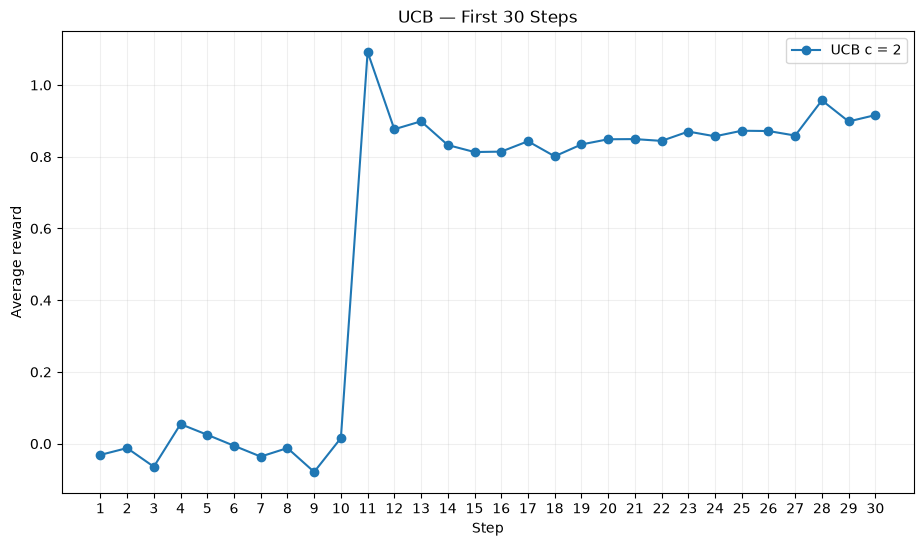

In [ ]:
plt.figure(figsize=(11, 6))
plt.plot(steps[:30], ucb_average_rewards[:30], marker="o", label="UCB c = 2")
plt.xlabel("Step")
plt.ylabel("Average reward")
plt.xticks(range(1, 31))
plt.title("UCB — First 30 Steps")
plt.grid(alpha=0.2)
plt.legend()
plt.show()